# Legacy vs long-double effective source — timeseries along one radial period

Three evaluators of the same $m$-mode puncture $\Phi^{S}_m$ and effective
source $S_m$ at one fixed field point, sampled along one radial period of the orbit:

| series | entry point | arithmetic |
|---|---|---|
| **legacy** | `EffectiveSource(mode="legacy")` → `effsource_calc_m` | original expressions, double |
| **ctx** | `effsource_equatorial_ctx_calc_m_offset` | complementary-modulus elliptic integrals, double |
| **gold** | `effsource_equatorial_ctx_calc_m_gold` | seven analytic channels reassembled in long double |

All three are given the **same particle and the same offsets**. The field point is
$r_f + i\,\delta\theta$ above the equator, so

$$\alpha(t) \;=\; \alpha_{20}\,\delta r(t)^2 \;+\; \alpha_{02}\,\delta\theta^2 ,
\qquad \delta r(t) = r_f - r_p(t),$$

is floored at $\alpha_{02}\delta\theta^2$ when the particle crosses $r_f$. Shrinking
$\delta\theta$ lowers that floor and tightens the closest approach.

`gold` is treated as truth.

In [1]:
import sys, os, math, time
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../../effectivesource'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from inspectre import Inspectre, EffectiveSource

C_LEGACY, C_CTX, C_GOLD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_MUTED = "#0b0b0b", "#52514e"
STYLE = {"legacy": (C_LEGACY, "-"), "ctx": (C_CTX, "--"), "gold": (C_GOLD, ":")}

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK, "axes.titlesize": 10,
    "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "legend.fontsize": 8, "legend.frameon": False,
    "lines.linewidth": 1.6, "text.color": INK,
})

## 1. Orbit, field point, closest approach

The field point sits **inside** the orbital range $[r_{\min}, r_{\max}]$, so the
particle crosses $r=r_f$ twice per radial period. Those crossings are where $\delta r$
vanishes and $\alpha$ hits its floor.

The crossing radial phase is analytic, $\psi_c = \arccos\!\big((p/r_f - 1)/e\big)$;
the corresponding Mino times are recovered by root-solving $r(\lambda) = r_f$, which is
monotonic on each half period.

In [2]:
a, p, e, m = 0.5, 10.0, 0.1, 2
r_field = 10.2

insp = Inspectre(spin=a, semilatus_rectum=p, eccentricity=e, mass=1.0)
Vr = insp.mino_period_r
Tr = 2.0 * np.pi / insp.omega_r
rmin, rmax = p / (1 + e), p / (1 - e)

lam_c1 = brentq(lambda L: insp.r_from_lambda(L) - r_field, 1e-12, Vr / 2,
                xtol=1e-15, rtol=8.9e-16)
lam_c2 = Vr - lam_c1
psi_c = math.acos((p / r_field - 1.0) / e)

print(f"orbit a={a} p={p} e={e},  m={m}")
print(f"r range [{rmin:.4f}, {rmax:.4f}];  r_field={r_field} "
      f"{'INSIDE' if rmin < r_field < rmax else 'OUTSIDE'}")
print(f"Tr={Tr:.4f}  Vr={Vr:.6f}")
print(f"psi_c={psi_c:.6f}  ->  lam_c = {lam_c1:.9f}, {lam_c2:.9f}")
print(f"residual r(lam_c1)-r_field = {insp.r_from_lambda(lam_c1)-r_field:.2e}")

orbit a=0.5 p=10.0 e=0.1,  m=2
r range [9.0909, 11.1111];  r_field=10.2 INSIDE
Tr=283.5005  Vr=2.358292
psi_c=1.768153  ->  lam_c = 0.668665215, 1.689626761
residual r(lam_c1)-r_field = -1.78e-15


## 2. Sampling grid and the three evaluators

A uniform $\lambda$ grid would step straight over the crossings — the approach is
resolved only within the last few nodes. The grid below is a uniform base union a
geometric cluster around each $\lambda_c$, reaching $10^{-10}\,V_r$ from the crossing.

At each node the particle is seated **once** and handed to both contexts, then all
three evaluators are called with the same $\delta r$ and $\delta\theta$. Both
$\delta r = r_f - r_p$ and $\delta\theta = \theta_f - \pi/2$ are exact in double here:
the operands are within a factor of two, so Sterbenz applies and the subtraction is
error-free. Note this also means $\delta\theta$ below $\sim10^{-8}$ cannot be
*requested* accurately through an absolute $\theta$ — `inspectre_c.make_field_point`
exists to carry the offset directly — but whatever offset the double $\theta_f$ lands
on, all three evaluators see it identically, which is what this comparison needs.

In [3]:
legacy = EffectiveSource(mass=1.0, spin=a, mode="legacy")
ctx = insp.es._ef
E, Lz = insp.energy, insp.angular_momentum


def graded_lambda(n_base=96, n_geo=28, span=0.2, floor=1e-10):
    """(grid params) -> sorted unique lambda nodes on [0, Vr], clustered at each lam_c."""
    pieces = [np.linspace(0.0, Vr, n_base + 1)]
    for lc in (lam_c1, lam_c2):
        d = span * np.geomspace(floor, 1.0, n_geo)
        pieces += [lc - d[::-1], np.array([lc]), lc + d]
    return np.unique(np.clip(np.concatenate(pieces), 0.0, Vr))


FIELDS = ("PhiS_re", "PhiS_im", "src_re", "src_im")


def sweep(dtheta, lam):
    """(dtheta, lambda grid) -> dict of t, alpha, dr and per-evaluator field arrays."""
    theta_field = np.pi / 2 + dtheta
    dtx = theta_field - np.pi / 2
    n = lam.size
    out = {"lam": lam, "t": np.empty(n), "alpha": np.empty(n), "dr": np.empty(n),
           "dtheta": dtx}
    for key in ("legacy", "ctx", "gold"):
        out[key] = {f: np.empty(n) for f in FIELDS}

    for i, L in enumerate(lam):
        r_p = insp.r_from_lambda(L)
        ph_p = insp.phi_from_lambda(L)
        ur = insp.four_velocity_equatorial(L)
        xp = legacy.make_coordinate(0.0, r_p, np.pi / 2, ph_p)
        legacy._ef.set_particle(xp, E, Lz, ur)
        ctx.set_particle(xp, E, Lz, ur)

        dr = r_field - r_p
        lg = legacy.calc_m(m, r_field, theta_field)
        cx = ctx.calc_m_offset(m, dr, dtx)
        gd = ctx.calc_m_gold(m, dr, dtx)
        al20, al02, _beta, _c = ctx.get_alpha()

        out["t"][i] = insp.t_from_lambda(L)
        out["dr"][i] = dr
        out["alpha"][i] = al20 * dr * dr + al02 * dtx * dtx
        for key, phis, src in (("legacy", lg["PhiS"], lg["src"]),
                               ("ctx", cx[0], cx[3]),
                               ("gold", gd[0], gd[2])):
            out[key]["PhiS_re"][i], out[key]["PhiS_im"][i] = phis[0], phis[1]
            out[key]["src_re"][i], out[key]["src_im"][i] = src[0], src[1]
    return out


def relerr(x, ref):
    """(x, ref) -> elementwise relative error, guarded against a vanishing reference."""
    return np.abs(x - ref) / np.maximum(np.abs(ref), 1e-300)

In [4]:
DTHETAS = (1e-2, 1e-3, 1e-4,1e-5, 1e-6)
lam = graded_lambda()
t_c1, t_c2 = insp.t_from_lambda(lam_c1), insp.t_from_lambda(lam_c2)

t0 = time.perf_counter()
runs = {dth: sweep(dth, lam) for dth in DTHETAS}
elapsed = time.perf_counter() - t0

print(f"{lam.size} nodes x {len(DTHETAS)} clearances x 3 evaluators "
      f"in {elapsed:.1f}s  ({elapsed/(lam.size*len(DTHETAS))*1e3:.1f} ms/node)")
print(f"crossings at t = {t_c1:.3f}, {t_c2:.3f}  (Tr = {Tr:.3f})\n")
print(f"{'dtheta':>8} {'alpha_min':>12} {'|dr|_min':>12}")
for dth, R in runs.items():
    print(f"{dth:8.0e} {R['alpha'].min():12.3e} {np.abs(R['dr']).min():12.3e}")

211 nodes x 5 clearances x 3 evaluators in 20.0s  (19.0 ms/node)
crossings at t = 72.480, 211.021  (Tr = 283.501)

  dtheta    alpha_min     |dr|_min
   1e-02    1.040e-02    1.776e-15
   1e-03    1.040e-04    1.776e-15
   1e-04    1.040e-06    1.776e-15
   1e-05    1.040e-08    1.776e-15
   1e-06    1.040e-10    1.776e-15


## 3. The fields themselves

$\mathrm{Re}\,\Phi^{S}_m(t)$ and $\mathrm{Re}\,S_m(t)$ over one radial period
at the middle clearance, all three evaluators overlaid. The two crossings show as the
peaks. At this scale the curves are indistinguishable — which is the point of §4.

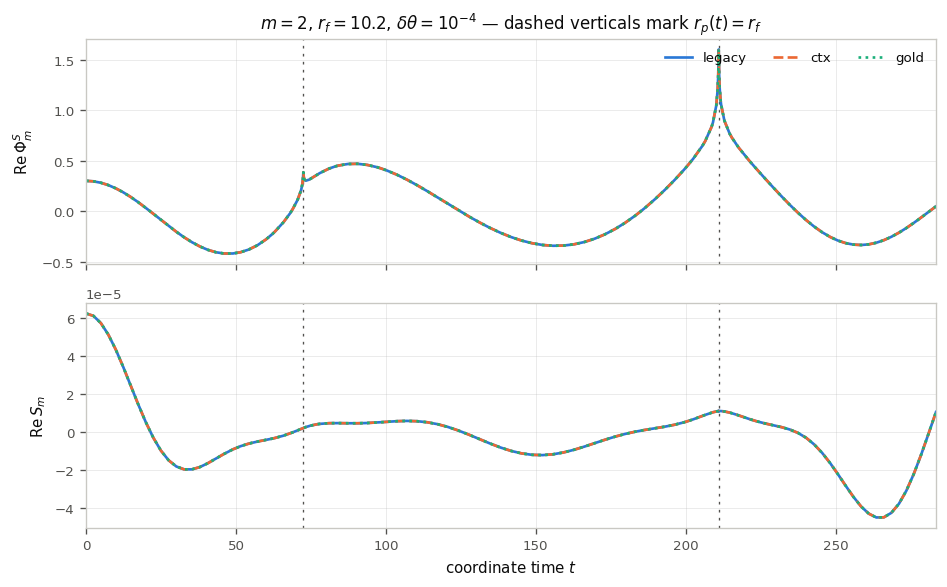

In [5]:
R = runs[1e-4]
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
for ax, key, lab in zip(axes, ("PhiS_re", "src_re"),
                        (r"$\mathrm{Re}\,\Phi^{S}_m$", r"$\mathrm{Re}\,S_m$")):
    for name in ("legacy", "ctx", "gold"):
        col, ls = STYLE[name]
        ax.plot(R["t"], R[name][key], ls, color=col, label=name)
    for tc in (t_c1, t_c2):
        ax.axvline(tc, color=INK_MUTED, lw=0.8, ls=(0, (2, 4)), zorder=0)
    ax.set_ylabel(lab)
axes[0].legend(loc="upper right", ncol=3)
axes[0].set_title(rf"$m={m}$, $r_f={r_field}$, $\delta\theta=10^{{-4}}$ "
                  r"— dashed verticals mark $r_p(t)=r_f$")
axes[1].set_xlabel("coordinate time $t$")
axes[1].set_xlim(0, Tr)
plt.tight_layout(); plt.show()

## 4. Where the accuracy goes

Relative error against `gold`, one column per clearance. The bottom row carries
$\alpha(t)$ on the same $x$.

Two different failures are visible:

- $\Phi^{S}_m$ — **legacy degrades as $\alpha$ falls; ctx does not.** The $m$-mode
  field is linear in the complete elliptic integrals $K(k)$, $E(k)$ at modulus
  $k=\sqrt{1/(1+C_1)}$, and $C_1\to0$ at the particle. Legacy forms $k$ and calls
  `gsl_sf_ellint_Kcomp`, by which point the complement $1-k^2$ has been rounded away
  to $\sim\epsilon/C_1$ relative error. ctx feeds the complementary parameter
  $m'=C_1/(1+C_1)$ to an AGM and never forms $k$ at all
  (`effsource_ellKE_from_C1`, `kerr-equatorial-ctx.c:77`). Measured directly on $K$:
  the two agree to $1.2\times10^{-16}$ at $C_1=10^{-2}$, but only to
  $2.9\times10^{-6}$ at $C_1=10^{-12}$.

  The log-separated form $\Phi^{S}_m=G_0+G_L\ln\alpha$ is **not** what ctx uses here.
  It lives in `calc_m_split` and enters this comparison only through `gold`.
- $S_m$ — **both double paths fail together.** The source reaches $1/\alpha^5$, and no
  rearrangement of double arithmetic survives that; only the long-double channel
  reassembly holds.

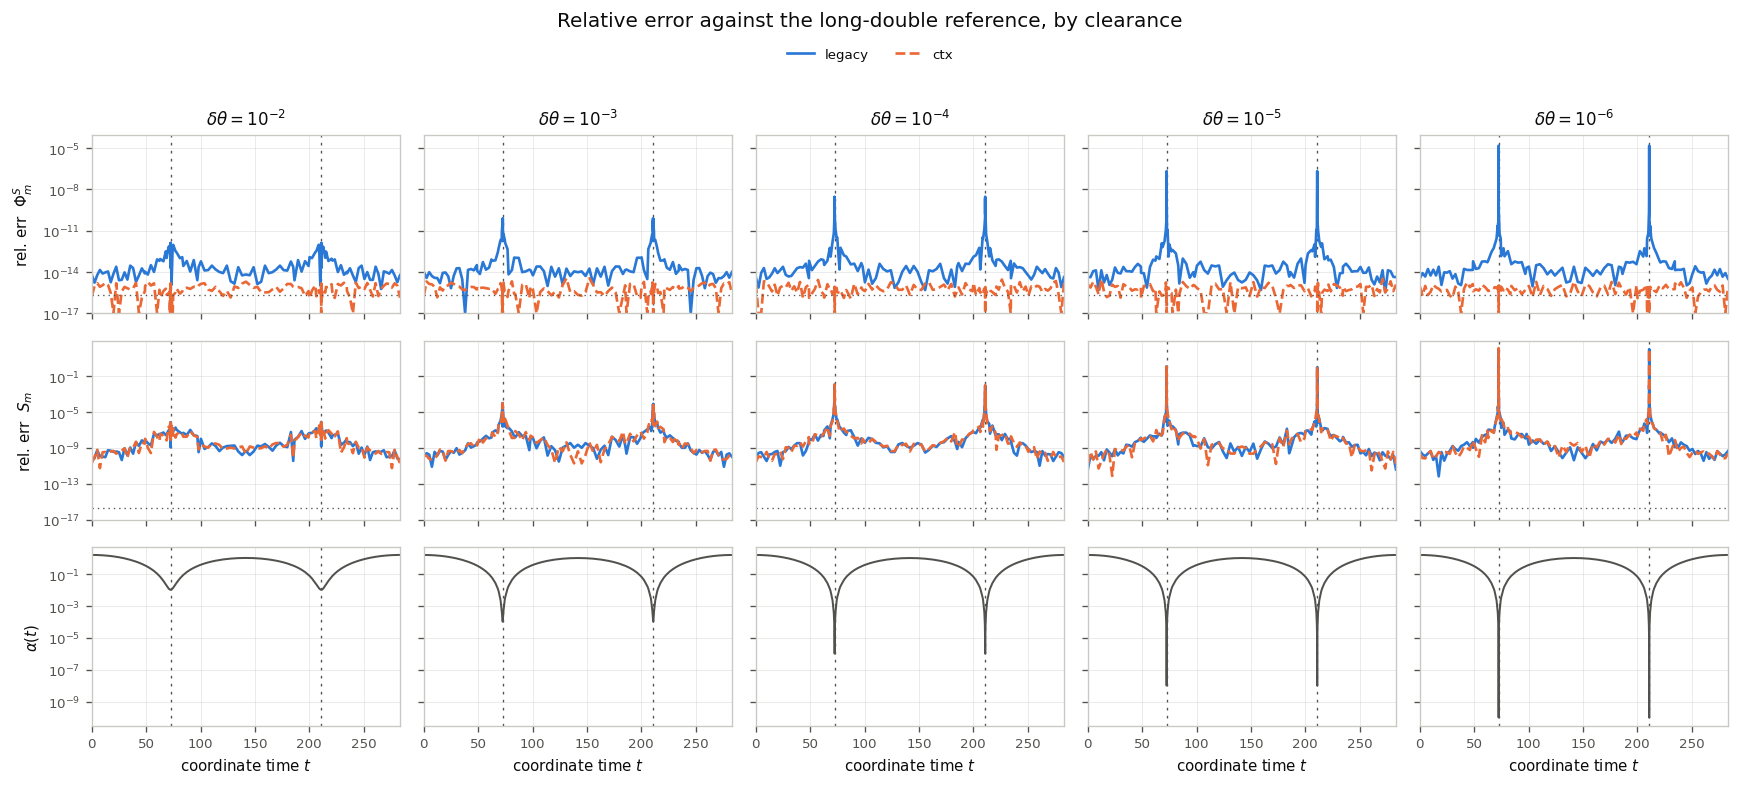

In [6]:
fig, axes = plt.subplots(3, len(DTHETAS), figsize=(2.6 * len(DTHETAS) + 1.6, 6.5),
                         sharex="col", sharey="row")
row_max = [0.0, 0.0, 0.0]
for j, dth in enumerate(DTHETAS):
    R = runs[dth]
    for i, (key, lab) in enumerate((("PhiS_re", r"rel. err  $\Phi^{S}_m$"),
                                    ("src_re", r"rel. err  $S_m$"))):
        ax = axes[i, j]
        for name in ("legacy", "ctx"):
            col, ls = STYLE[name]
            er = np.maximum(relerr(R[name][key], R["gold"][key]), 1e-17)
            row_max[i] = max(row_max[i], er.max())
            ax.semilogy(R["t"], er, ls, color=col, label=name)
        ax.axhline(2.2e-16, color=INK_MUTED, lw=0.8, ls=(0, (1, 3)))
        if j == 0:
            ax.set_ylabel(lab)
    ax = axes[2, j]
    ax.semilogy(R["t"], R["alpha"], "-", color=INK_MUTED, lw=1.2)
    row_max[2] = max(row_max[2], R["alpha"].max())
    if j == 0:
        ax.set_ylabel(r"$\alpha(t)$")
    ax.set_xlabel("coordinate time $t$")
    axes[0, j].set_title(rf"$\delta\theta = 10^{{{int(round(np.log10(dth)))}}}$")
    for i in range(3):
        for tc in (t_c1, t_c2):
            axes[i, j].axvline(tc, color=INK_MUTED, lw=0.8, ls=(0, (2, 4)), zorder=0)
        axes[i, j].set_xlim(0, Tr)
for i in range(2):
    axes[i, 0].set_ylim(1e-17, row_max[i] * 6)
axes[2, 0].set_ylim(top=row_max[2] * 3)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.suptitle("Relative error against the long-double reference, by clearance", y=1.0)
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 0.968))
plt.tight_layout(rect=(0, 0, 1, 0.945)); plt.show()

## 5. Error against $\alpha$

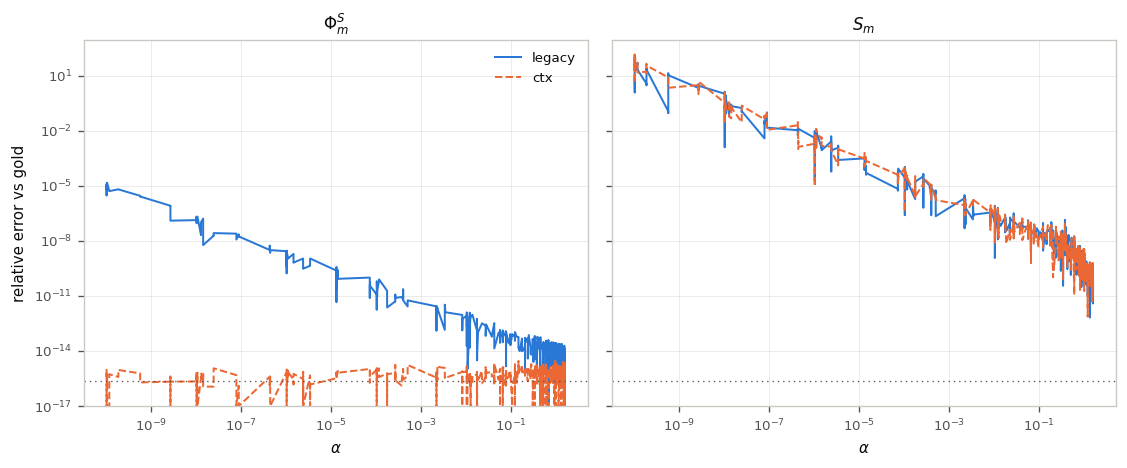

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4), sharey=True)
gmax = 0.0
for ax, key, lab in zip(axes, ("PhiS_re", "src_re"),
                        (r"$\Phi^{S}_m$", r"$S_m$")):
    for name in ("legacy", "ctx"):
        col, ls = STYLE[name]
        al = np.concatenate([runs[d]["alpha"] for d in DTHETAS])
        er = np.concatenate([relerr(runs[d][name][key], runs[d]["gold"][key])
                             for d in DTHETAS])
        o = np.argsort(al)
        y = np.maximum(er[o], 1e-17)
        gmax = max(gmax, y.max())
        ax.loglog(al[o], y, ls, color=col, label=name, lw=1.2)
    ax.axhline(2.2e-16, color=INK_MUTED, lw=0.8, ls=(0, (1, 3)))
    ax.set_xlabel(r"$\alpha$"); ax.set_title(lab)
axes[0].set_ylim(1e-17, gmax * 6)
axes[0].set_ylabel("relative error vs gold")
axes[0].legend(loc="upper right")
plt.tight_layout(); plt.show()

## 6. $n$-mode Errors

The $n$-mode amplitude is

$$A_n = \frac{1}{T_r}\int_0^{T_r} e^{\,i(m\Omega_\phi + n\Omega_r)t}\,S_m(t)\,dt .$$

Forming it from each timeseries with **one common quadrature** over the same nodes
isolates the field error. The close-approach region is a small part of the period, so the
integral averages much of the pointwise error; the
surviving error grows with $|n|$, since higher $n$ weights the peak more sharply.

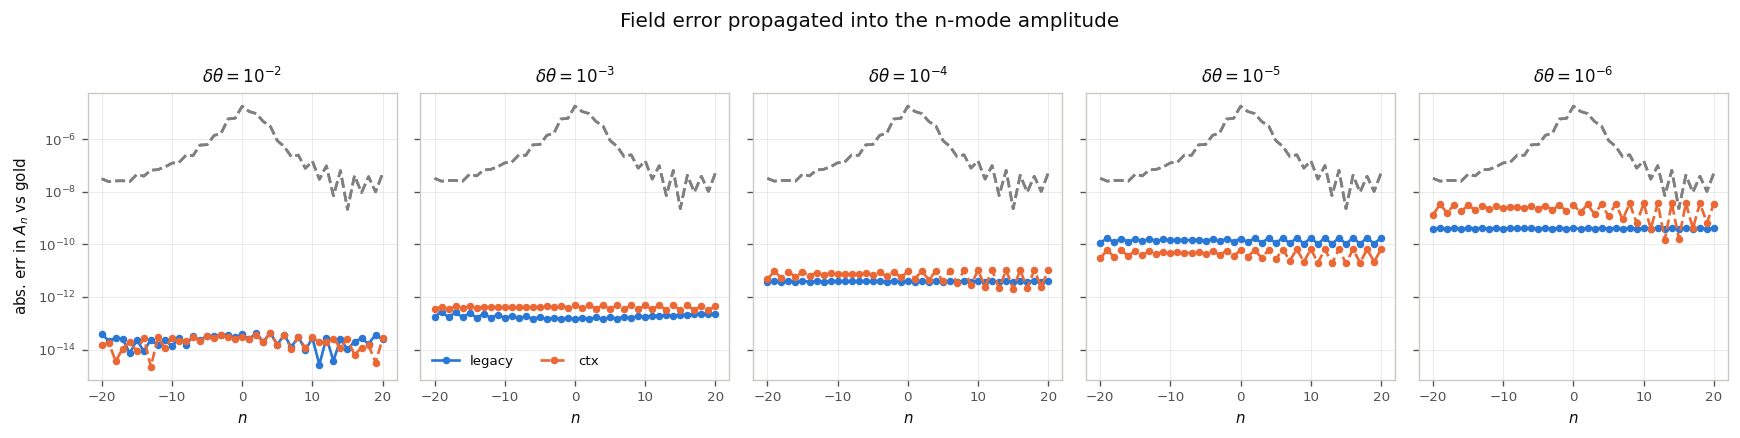

In [8]:
def amplitude(R, name, n):
    """(run, evaluator, n) -> complex A_n by trapezoid over the shared node times."""
    omega = m * insp.omega_phi + n * insp.omega_r
    phase = np.exp(1j * omega * R["t"])
    g = phase * (R[name]["src_re"] + 1j * R[name]["src_im"])
    return (np.trapezoid(g.real, x=R["t"]) + 1j * np.trapezoid(g.imag, x=R["t"])) / Tr


ns = np.arange(-20, 21)
fig, axes = plt.subplots(1, len(DTHETAS), figsize=(2.6 * len(DTHETAS) + 1.6, 3.6), sharey=True)
for ax, dth in zip(axes, DTHETAS):
    R = runs[dth]
    ref = np.array([amplitude(R, "gold", int(n)) for n in ns])
    for name in ("legacy", "ctx"):
        col, ls = STYLE[name]
        val = np.array([amplitude(R, name, int(n)) for n in ns])
        ax.semilogy(ns, np.maximum(np.abs(val - ref), 1e-18),
                    ls, color=col, marker="o", ms=3.5, label=name)
        ax.semilogy(ns, np.maximum(np.abs(ref), 1e-18), ls='--', color='grey')
    ax.set_xlabel("$n$")
    ax.set_title(rf"$\delta\theta = 10^{{{int(round(np.log10(dth)))}}}$")
axes[0].set_ylabel(r"abs. err in $A_n$ vs gold")
axes[1].legend(loc="lower left", ncol=2)
fig.suptitle("Field error propagated into the n-mode amplitude", y=1.0)
plt.tight_layout(); plt.show()

## 7. Table view

Worst-case relative error over the period, per clearance.

In [9]:
print(f"{'dtheta':>8} {'alpha_min':>11} | {'PhiS legacy':>12} {'PhiS ctx':>11}"
      f" | {'src legacy':>11} {'src ctx':>11}")
print("-" * 78)
for dth in DTHETAS:
    R = runs[dth]
    vals = []
    for key in ("PhiS_re", "src_re"):
        for name in ("legacy", "ctx"):
            vals.append(relerr(R[name][key], R["gold"][key]).max())
    print(f"{dth:8.0e} {R['alpha'].min():11.3e} | {vals[0]:12.3e} {vals[1]:11.3e}"
          f" | {vals[2]:11.3e} {vals[3]:11.3e}")

print(f"\n{'dtheta':>8} | {'A_0 legacy':>11} {'A_0 ctx':>11} | {'A_6 legacy':>11} {'A_6 ctx':>11}")
print("-" * 68)
for dth in DTHETAS:
    R = runs[dth]
    row = []
    for n in (0, 6):
        ref = amplitude(R, "gold", n)
        for name in ("legacy", "ctx"):
            row.append(abs(amplitude(R, name, n) - ref) / abs(ref))
    print(f"{dth:8.0e} | {row[0]:11.3e} {row[1]:11.3e} | {row[2]:11.3e} {row[3]:11.3e}")

  dtheta   alpha_min |  PhiS legacy    PhiS ctx |  src legacy     src ctx
------------------------------------------------------------------------------
   1e-02   1.040e-02 |    1.278e-12   1.986e-15 |   8.137e-07   7.508e-07
   1e-03   1.040e-04 |    7.942e-11   3.525e-15 |   1.075e-04   9.486e-05
   1e-04   1.040e-06 |    2.906e-09   2.854e-15 |   1.211e-02   1.255e-02
   1e-05   1.040e-08 |    2.092e-07   3.179e-15 |   1.330e+00   1.222e+00
   1e-06   1.040e-10 |    1.465e-05   1.981e-15 |   1.101e+02   1.438e+02

  dtheta |  A_0 legacy     A_0 ctx |  A_6 legacy     A_6 ctx
--------------------------------------------------------------------
   1e-02 |   2.052e-09   1.593e-09 |   6.902e-08   6.742e-08
   1e-03 |   7.643e-09   2.643e-08 |   2.797e-07   8.961e-07
   1e-04 |   2.245e-07   5.082e-07 |   7.791e-06   1.878e-05
   1e-05 |   9.074e-06   3.217e-06 |   3.271e-04   1.187e-04
   1e-06 |   2.238e-05   1.769e-04 |   7.692e-04   6.584e-03
